In [2]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../analysisFunctions'))
sys.path.insert(0, dir1)
sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from hyperion_utils import *
import doubleml as dml
import pymc as pm
import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import causalpy as cp
import pymc_bart as pmb

In [3]:
myDfs = readDfs()

In [4]:
print(myDfs['Description_tables_variables'][['Tables', 'Variable', 'LabelTranslated', 'Label']].to_string())

         Tables                          Variable                                                                                      LabelTranslated                                                                                                 Label
0           ADL                            SUBJID                                                                     Subject Identifier for the Study                                                                      Subject Identifier for the Study
1           ADL                             ADL_0                                                                    Has the ADL score been completed?                                                                      Le score ADL a t-il été complété
2           ADL                        ADL_1_TEMP                                                      Personal hygiene (intermediate field for entry)                                                  Hygiène corporelle (champ intermediaire p

In [5]:
bio_data_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[52:76])
bio_data_columns.append('SUBJID')
bio_data_columns_descr = list(myDfs['Description_tables_variables']['Label'].iloc[52:76])
bio_visit_column = 'VISIT'
cpc_column = 'CPC_SC3'
group_colums = ['V0_BRAS2', 'groupe']
ds_columns = 'DS_DATA_REFUS'
ecg_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[137:154])
ecg_columns_descr = list(myDfs['Description_tables_variables']['LabelTranslated'].iloc[137:154])
j0_drop_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[362:384])
j0_reflex_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[273:285])
j0_reflex_columns_descr = list(myDfs['Description_tables_variables']['LabelTranslated'].iloc[273:285])
sofa_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[586:593])
sofa_columns.append('SUBJID')
ei_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[158:168])
ei_columns = ei_columns + (['SUBJID', 'EI_ARYTHMI', 'EI_ANTIEPILEPTIQ'])

In [6]:
myPredictorsDf = myDfs['ds'][myDfs['ds']['DS_DATA_REFUS'] != 1][['SUBJID', 'DS_DATA_REFUS']]
myPredictorsDf = myPredictorsDf.merge(myDfs['bras_rando'], on='SUBJID')
myPredictorsDf = myPredictorsDf[~myPredictorsDf['groupe'].isna()]
myPredictorsDf = myPredictorsDf.merge(myDfs['cpc'][['SUBJID', cpc_column]], on='SUBJID')
myPredictorsDf = myPredictorsDf.merge(myDfs['j0'], on='SUBJID')
myPredictorsDf = myPredictorsDf.merge(myDfs['bio'][myDfs['bio']['VISIT'] == 'J0'][bio_data_columns], on='SUBJID')
myPredictorsDf = myPredictorsDf.merge(myDfs['ecg'][myDfs['ecg']['VISIT'] == 'J0'][ecg_columns], on='SUBJID')
myPredictorsDf = myPredictorsDf.merge(myDfs['sofa'][myDfs['sofa']['VISIT'] == 'J0'][sofa_columns], on='SUBJID')
myPredictorsDf = myPredictorsDf.merge(myDfs['ei'][myDfs['ei']['CRFSTATUS'] == 'J0'][ei_columns], on='SUBJID')
# myPredictorsDf = myPredictorsDf.merge(myDfs['adl'][['SUBJID', 'ADL_SC']], on='SUBJID')
myPredictorsDf = myPredictorsDf.merge(myDfs['barthel'][['SUBJID', 'BARTHEL_SC']], on='SUBJID')
# myPredictorsDf = myPredictorsDf.merge(myDfs['mms'][['SUBJID', 'MMS_SC']], on='SUBJID')
myDay0SofaSc = myDfs['sofa'][(myDfs['sofa']['VISIT'] == 'J0')][['SUBJID', 'SOFA_SC']]
myDay7SofaSc = myDfs['sofa'][(myDfs['sofa']['VISIT'] == 'J7')][['SUBJID', 'SOFA_SC']]
myDay7SofaSc.rename(columns={'SOFA_SC': 'SOFA_SC7'}, inplace=True)
myPredictorsDf = myPredictorsDf.merge(myDay7SofaSc, on='SUBJID')
myPredictorsDf = myPredictorsDf.merge(myDay0SofaSc, on='SUBJID')
myPredictorsDf = myPredictorsDf.merge(myDfs['ds'][['DS_DC', 'DS_DT_DC', 'SUBJID']], on='SUBJID')
myPredictorsDf = myPredictorsDf.merge(myDfs['date'][['DT_J0', 'SUBJID']], on='SUBJID')
myPredictorsDf['DAYS_ALIVE_30'] = (pd.to_datetime(myPredictorsDf['DS_DT_DC'], format='%d/%m/%Y') - pd.to_datetime(pd.to_datetime(myPredictorsDf['DT_J0']).dt.date)).dt.days
myPredictorsDf['DAYS_ALIVE_30'].fillna(30, inplace=True)
myPredictorsDf.loc[myPredictorsDf['DAYS_ALIVE_30'] > 30, 'DAYS_ALIVE_30'] = 30

C:\Users\mbranda1\AppData\Local\Temp\ipykernel_10756\735126075.py:20: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  myPredictorsDf['DAYS_ALIVE_30'] = (pd.to_datetime(myPredictorsDf['DS_DT_DC'], format='%d/%m/%Y') - pd.to_datetime(pd.to_datetime(myPredictorsDf['DT_J0']).dt.date)).dt.days
C:\Users\mbranda1\AppData\Local\Temp\ipykernel_10756\735126075.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  myPre

In [7]:
myPredictorsDf.drop(columns=['DS_DT_DC', 'DT_J0', 'DS_DATA_REFUS', 'Unnamed: 0_x', 'Unnamed: 0_y', 'V0_BRAS2', 'DATEDERANDOAPRENDREENCOMPTEPOURA', 'J0_PANCARTE', 'J0_PANCARTET1', 'J0_NAIS_M', 'J0_NAIS_A', 'J0_DNAIS'], inplace=True)
myPredictorsDf.drop(columns=j0_drop_columns, inplace=True)
myPredictorsDf['CPC_SC3'].fillna(5, inplace=True)

C:\Users\mbranda1\AppData\Local\Temp\ipykernel_10756\2679657076.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  myPredictorsDf['CPC_SC3'].fillna(5, inplace=True)


In [8]:
myDfs['sofa'][(myDfs['sofa']['VISIT'] == 'J7') & (myDfs['sofa']['SOFA_NEURO'] < 3)]['SOFA_NEURO'].shape

(66,)

In [9]:
myPredictorsDf['CPC12'] = ((myPredictorsDf['CPC_SC3'] == 1) | (myPredictorsDf['CPC_SC3'] == 2)).astype(int)
# myPredictorsDf['CPC12Hyp'] = (((myPredictorsDf['CPC_SC3'] == 1) | (myPredictorsDf['CPC_SC3'] == 2)) & (myPredictorsDf['groupe'] == 1)).astype(int)
# myPredictorsDf['CPC12Norm'] = (((myPredictorsDf['CPC_SC3'] == 1) | (myPredictorsDf['CPC_SC3'] == 2)) & (myPredictorsDf['groupe'] == 0)).astype(int)
myPredictorsDf['SEX'] = (myPredictorsDf['J0_SEX'] == 'Homme').astype(int)


In [94]:
myXValue = myPredictorsDf.drop(columns= ['CPC_SC3', 'CPC12', 'J0_SEX', 'J0_CAUSE2_ACR_P', 'J0_H_37T1', 'VISIT', 'SUBJID', 'BARTHEL_SC', 'SOFA_SC7', 'DS_DC', 'DAYS_ALIVE_30'])
# myYValue = myPredictorsDf['CPC_SC3'].astype(int) - 1
myFilter = myPredictorsDf['groupe'] != 2
myXValue = myXValue[myFilter]
myNumericalColumns = myXValue.columns[myXValue.nunique() > 10]
# myNumericalColumns.drop(columna='SOFA_SC', inplace=True)
myCategoricalColumns = myXValue.columns[(myXValue.nunique() <= 10)]
# myYValue = myPredictorsDf[myFilter]['SOFA_SC7'].fillna(24)
myYValue = myPredictorsDf['CPC12']
myXValue = myXValue.fillna(0)
X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['CPC12', 'groupe']], test_size=0.20)

In [95]:
with pm.Model() as model:
  X_shared = pm.MutableData('X_shared', X_train)
  y_shared = pm.MutableData('y_shared', y_train)
  u = pmb.BART('u', X = X_shared, Y= y_train, m=20)
  p = 1 / (1 + np.exp(-u))
  # p = pm.Deterministic("p", pm.math.exp(u))
  # y_obs= pm.Poisson('y_obs', mu=p, observed = y_shared)

  y_obs= pm.Bernoulli('y_obs', p=p, observed = y_shared)
  trace = pm.sample(1000, return_inferencedata=True)

C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pymc\data.py:304: FutureWarning: MutableData is deprecated. All Data variables are now mutable. Use Data instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:94: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pymc\step_methods\compound.py:72: DeprecationWarning: `PGBART.stats_dtypes` is deprecated. Please update it to specify `stats_dtypes_shapes` instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppDa

Output()

C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:94: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:94: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\ran

In [86]:
with model:
    pm.set_data({'X_shared': X_train, 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    # Calculate the mean predicted probability
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_train, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_train, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [y_obs]


Output()

ROC AUC: 0.91
Accuracy: 0.85


In [83]:
with model:
    pm.set_data({'X_shared': X_test, 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:94: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(
Sampling: [u, y_obs]


Output()

ROC AUC: 0.86
Accuracy: 0.80


In [84]:
myXValueModified1 = X_train.copy()
myXValueModified1['groupe'] = 1.0
myXValueModified2 = X_train.copy()
myXValueModified2['groupe'] = 0.0
with model:
    pm.set_data({'X_shared': myXValueModified1, 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs1 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

with model:
    pm.set_data({'X_shared': myXValueModified2, 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs2 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data



C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:94: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(
Sampling: [u, y_obs]


Output()

C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:94: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(
Sampling: [u, y_obs]


Output()

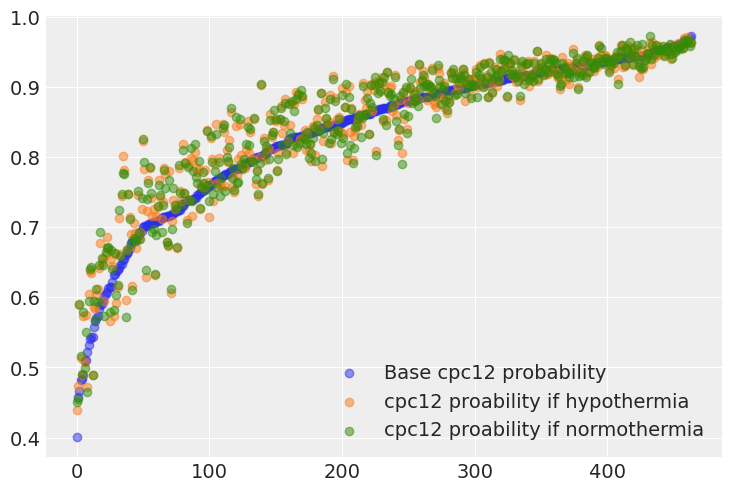

In [87]:
myYPred =  (predicted_probs1 - predicted_probs2)
myYPred = predicted_probs
myDfPreds = pd.DataFrame()
myDfPreds['base'] = predicted_probs
myDfPreds['group1'] = predicted_probs1
myDfPreds['group2'] = predicted_probs2
myDfPreds.sort_values(by=['base'], inplace=True)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['base'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group1'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group2'], alpha = 0.5)
plt.legend(['Base cpc12 probability', 'cpc12 proability if hypothermia', 'cpc12 proability if normothermia'])


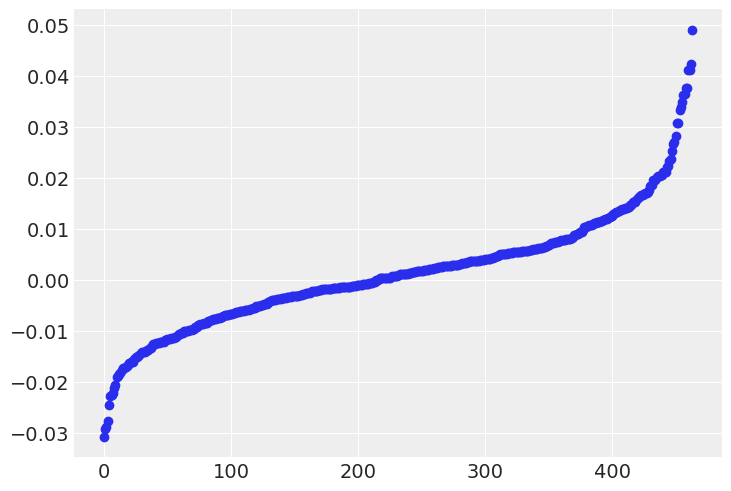

In [93]:
myDfPreds['diffs'] = (myDfPreds['group1'] - myDfPreds['group2'])
myDfPreds['diffsscaled'] =  myDfPreds['diffs'] / myDfPreds['base']
myDfPreds.sort_values(by=['diffsscaled'], inplace=True)
# myDfPreds.sort_values(by=['diffs'], inplace=True)
# plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['diffs'])
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['diffsscaled'])

In [89]:
fpr, tpr, thresholds = roc_curve(y_test, predicted_probs)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [117, 464]

In [81]:
import arviz as az
az.to_netcdf(trace, 'bart_model_tracedc.nc')

'bart_model_tracedc.nc'

In [156]:
# Extract variable importance (Posterior Inclusion Probabilities)
pips = u.pip
print("Posterior Inclusion Probabilities (PIP) for each variable:")
for i, pip in enumerate(pips):
    print(f"Feature {i}: {pip:.3f}")

AttributeError: 'TensorVariable' object has no attribute 'pip'

In [71]:
p_pred['posterior_predictive']['y_obs'].mean(axis=1).mean(axis=0).data

array([0.032     , 0.07733333, 0.01333333, 0.022     , 0.03866667,
       0.00733333, 0.19133333, 0.044     , 0.00933333, 0.01266667,
       0.30266667, 0.09733333, 0.018     , 0.07733333, 0.01933333,
       0.162     , 0.02866667, 0.012     , 0.29466667, 0.05466667,
       0.068     , 0.00333333, 0.028     , 0.01466667, 0.046     ,
       0.01133333, 0.002     , 0.02666667, 0.046     , 0.10266667,
       0.056     , 0.014     , 0.048     , 0.14266667, 0.00533333,
       0.05533333, 0.47266667, 0.03133333, 0.09133333, 0.008     ,
       0.03666667, 0.024     , 0.13066667, 0.13933333, 0.01266667,
       0.03933333, 0.02533333, 0.016     , 0.31266667, 0.02333333,
       0.09      , 0.024     , 0.012     , 0.03266667, 0.07      ,
       0.02      , 0.024     , 0.05066667, 0.01      , 0.086     ,
       0.102     , 0.04      , 0.006     , 0.00733333, 0.03133333,
       0.00533333, 0.012     , 0.02666667, 0.006     , 0.01      ,
       0.04533333, 0.02266667, 0.056     , 0.00866667, 0.006  

In [34]:
myData = myPredictorsDf.drop(columns= ['CPC_SC3', 'J0_SEX', 'J0_CAUSE2_ACR_P', 'J0_H_37T1', 'SUBJID', 'BARTHEL_SC', 'SOFA_SC7'])
myData['post_treatment'] = myPredictorsDf['CPC12']
causal = cp.DifferenceInDifferences(
  data=myData,
  group_variable_name = 'groupe', 
  treatment_column = 'CPC12',
  time_variable_name = 'VISIT',
  formula='y ~ 1+ post_treatment*group',
  model = cp.pymc_models.LinearRegression()
)

DataException: Require a `unit` column to label unique units. This is used for plotting purposes

In [45]:
model = SklearnModel()
model.fit(X_train, y_train)

SklearnModel()

In [25]:
myNewXTrain = X_train.copy()
myNewXTrain['CPC_SC3'] = y_train
data_dml_base = dml.DoubleMLData(
    myNewXTrain,
    y_col='CPC_SC3',
    d_cols='groupe'
)

In [26]:
randomForest_reg = RandomForestRegressor(n_estimators=200)
randomForest_class = RandomForestClassifier(n_estimators=200)
dml_irm = dml.DoubleMLIRM(data_dml_base,
                          ml_g=randomForest_reg,
                          ml_m=randomForest_class,
                          trimming_threshold=0.05,
                          n_folds=5)
print("Training IRM Model")
dml_irm.fit()

Training IRM Model


In [31]:
cate = dml_irm.cate(pd.DataFrame(X_train['groupe']))
df_cate = cate.confint(pd.DataFrame(X_test['groupe']), level=0.95, joint=True, n_rep_boot=2000)
print(df_cate)

     2.5 %   effect  97.5 %
431    NaN  0.00000     NaN
524    NaN  0.00000     NaN
339    NaN  0.00000     NaN
530    NaN  0.00000     NaN
333    NaN  0.00000     NaN
..     ...      ...     ...
557    NaN  0.00000     NaN
326    NaN  0.09928     NaN
28     NaN  0.09928     NaN
35     NaN  0.00000     NaN
220    NaN  0.09928     NaN

[117 rows x 3 columns]


C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\doubleml\utils\blp.py:217: RuntimeWarning: divide by zero encountered in divide
  (1.0 / blp_se))
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\doubleml\utils\blp.py:216: RuntimeWarning: invalid value encountered in multiply
  bootstrap_samples = np.multiply(np.dot(np_basis, np.dot(sqrtm(self._blp_omega), normal_samples)).T,


In [27]:
dml_irm.summary

,coef,std err,t,P>|t|,2.5 %,97.5 %
groupe,-0.023749,0.097295,-0.244095,0.807157,-0.214443,0.166945


In [49]:
import patsy
# design_matrix = patsy.dmatrix("bs(x, df=5, degree=2)", {"x": data["X_0"]})
# spline_basis = pd.DataFrame(design_matrix)
# new_data = X_test.copy()
# new_data['CPC12'] = y_test
# spline_grid = pd.DataFrame(patsy.build_design_matrices([design_matrix.design_info], new_data)[0])


     2.5 %    effect  97.5 %
334    NaN  0.014057     NaN
285    NaN  0.012871     NaN
160    NaN  0.019534     NaN
542    NaN  0.018621     NaN
337    NaN  0.015335     NaN
..     ...       ...     ...
573    NaN  0.015883     NaN
68     NaN  0.000000     NaN
91     NaN  0.018530     NaN
388    NaN  0.000000     NaN
255    NaN  0.018804     NaN

[117 rows x 3 columns]


C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\doubleml\utils\blp.py:217: RuntimeWarning: divide by zero encountered in divide
  (1.0 / blp_se))
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\doubleml\utils\blp.py:216: RuntimeWarning: invalid value encountered in multiply
  bootstrap_samples = np.multiply(np.dot(np_basis, np.dot(sqrtm(self._blp_omega), normal_samples)).T,


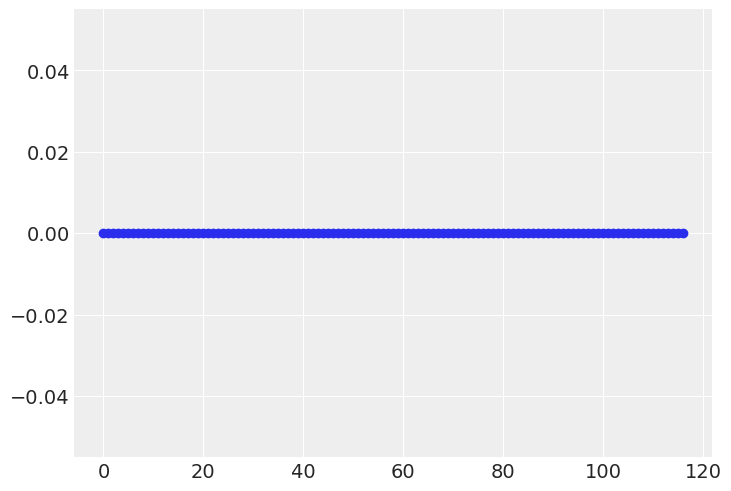

In [46]:
myXValueModified1 = X_test.copy()
myXValueModified1['groupe'] = 1.0
myXValueModified2 = X_test.copy()
myXValueModified2['groupe'] = 0.0
y_pred_proba1 = model.predict(myXValueModified1)
y_pred_proba2 = model.predict(myXValueModified2)
y_pred_proba1 - y_pred_proba2
plt.scatter(x = range(len(y_pred_proba1)), y = y_pred_proba1 - y_pred_proba2)

In [50]:
y_train

112    1
179    0
389    0
96     0
196    0
      ..
505    0
330    0
103    0
359    0
550    0
Name: CPC12, Length: 464, dtype: int32

In [ ]:
y_pred = model.predict(X_train)
r2_score(y_pred, y_train)

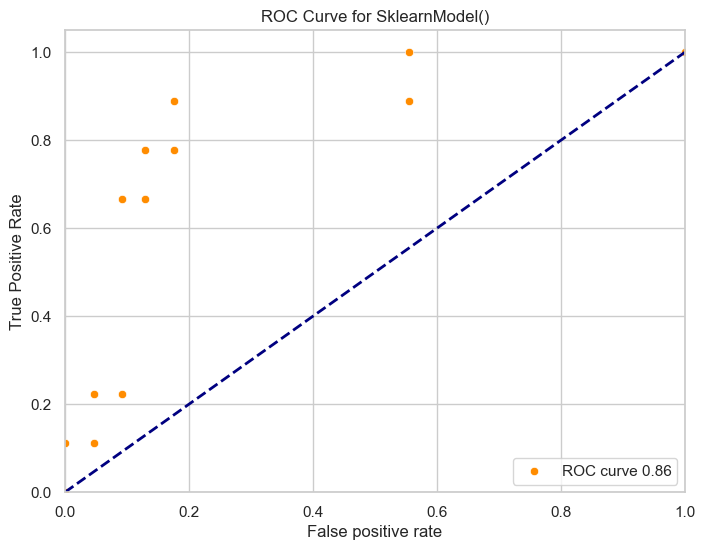

In [25]:
y_pred_proba = model.predict(X_test)
myFpr, myTpr, myThresholds = roc_curve(y_test, y_pred_proba)
myRocAuc = auc(myFpr, myTpr)
sns.set(style='whitegrid')
plt.figure(figsize=(8,6))
sns.scatterplot(x= myFpr, y= myTpr, color='darkorange', lw=2, label = f'ROC curve {myRocAuc:.2f}')
sns.lineplot(x= [0, 1], y= [0,1], color='navy', lw=2, linestyle = '--')
plt.xlim([0, 1.0])
plt.ylim([0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.title(f'ROC Curve for {model}')
plt.show()

In [72]:
myGridSearchCv = gridSearchKFoldRegression(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='neg_mean_squared_error', aGrid=myNewGrid, aNumericalColumns=myNumericalColumns)
myBestModel = myGridSearchCv.best_estimator_

c:\Program Files\miniconda3\lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best parameters: {'clf': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...), 'clf__max_depth': 2, 'clf__n_estimators': 10}
Best cross val roc auc score: -86.4410


In [73]:
y_pred = myBestModel.predict(X_test)
mean_squared_error(y_test, y_pred)

86.27320484734004

array([18.539667 , 10.476525 ,  8.282269 , 20.04175  ,  8.653562 ,
       13.535429 , 23.193998 , 12.379025 , 17.558783 , 13.404882 ,
       21.05506  , 13.69215  , 10.276186 ,  5.5297837, 21.04222  ,
        9.094517 , 10.727406 , 17.441969 ,  4.7350583, 12.19637  ,
       14.952703 ,  8.830632 ,  9.743409 ,  6.0625587, 15.290517 ,
       11.15546  ,  6.842315 ,  8.042764 , 19.097662 , 14.122929 ,
        6.335068 ,  5.93773  ,  9.583831 ,  5.7063494,  6.3142858,
       11.15546  ,  9.789528 ,  7.8107553,  9.507484 , 12.291427 ,
        6.849924 ,  9.771354 , 17.39088  ,  7.6470885,  5.7063494,
       16.567724 ,  9.27416  ,  7.98589  ,  6.781966 ,  9.340559 ,
        4.978329 , 17.573162 ,  7.9004326,  4.978329 ,  7.290879 ,
       15.360807 , 18.503963 ,  8.16297  , 25.429415 , 12.018036 ,
       12.371505 , 16.638544 , 17.628798 ,  6.0681763,  9.146998 ,
        5.7063494, 17.74713  , 10.437124 ,  4.686977 ,  5.822943 ,
        9.614393 , 16.393278 , 15.290517 ,  7.290879 ,  4.0879

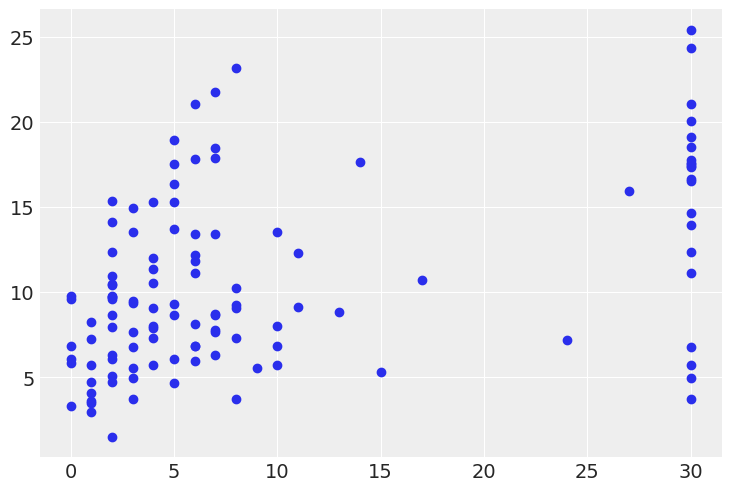

In [74]:
plt.scatter(x = y_test,  y = y_pred)
y_pred

In [75]:
y_pred - y_test

533   -11.460333
299     8.476525
293     7.282269
29     -9.958250
471     1.653562
         ...    
503    14.786861
20    -16.072487
319    -4.273854
428    11.828548
322     6.533905
Name: DAYS_ALIVE_30, Length: 117, dtype: float64

c:\Program Files\miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Program Files\miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Program Files\miniconda3\lib\site-packages\seaborn\_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


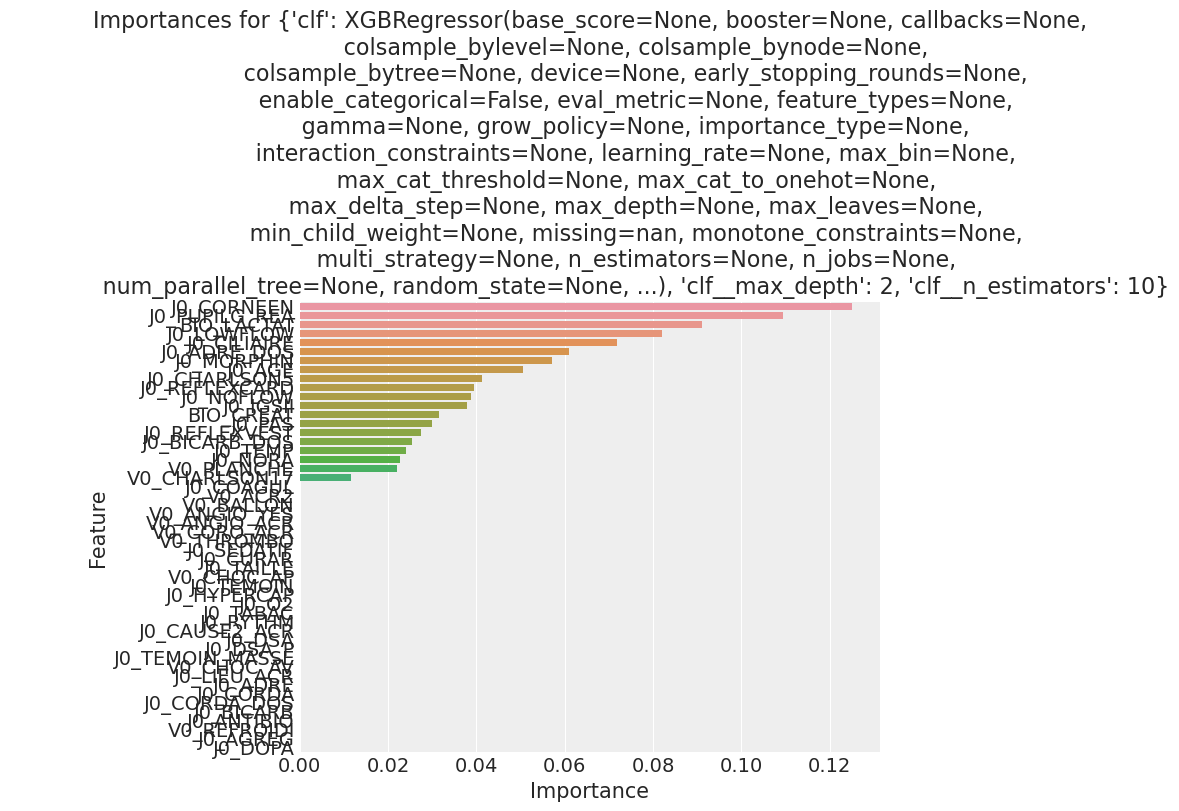

In [76]:
def getTopFeatures(aGridSearch, aColumnNames):
  myBestModel = aGridSearch.best_estimator_
  if hasattr(myBestModel.named_steps['clf'], 'coef_'):
    myImportances = myBestModel.named_steps['clf'].coef_[0]
  else:
    myImportances = myBestModel.named_steps['clf'].feature_importances_
  myFeatureImportancesDf = pd.DataFrame({
    'Feature': aColumnNames,
    'Importance': myImportances
  })
  myFeatureImportancesDf.sort_values(by='Importance', ascending=False, inplace=True)
  myTopFeatures = myFeatureImportancesDf.head(50)
  plt.figure(figsize=(8, 8))
  sns.barplot(x = 'Importance', y= 'Feature', data=myTopFeatures)
  plt.title(f'Importances for {aGridSearch.best_params_}')
  return myFeatureImportancesDf
myFeatureImportancesDf = getTopFeatures(myGridSearchCv,  list(myNumericalColumns) + list(myCategoricalColumns))

In [77]:
myFeatureImportancesDf[myFeatureImportancesDf['Feature'] == 'groupe']
# myFeatureImportancesDf

,Feature,Importance
45,groupe,0.0


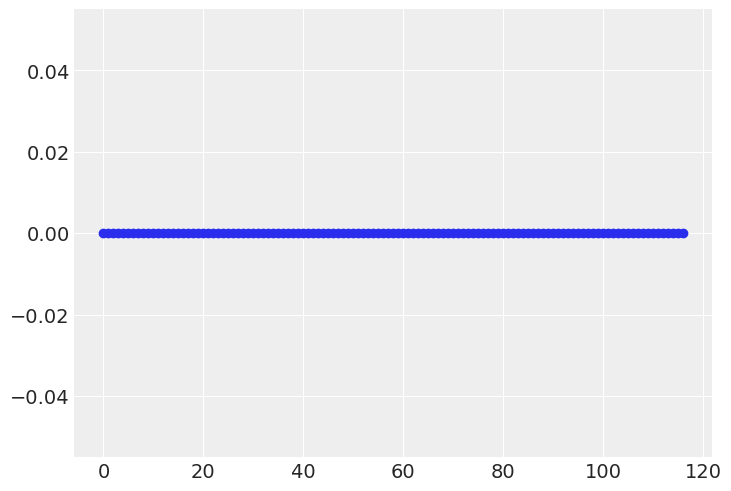

In [78]:
myXValueModified1 = X_test.copy()
myXValueModified1['groupe'] = 1.0
myXValueModified2 = X_test.copy()
myXValueModified2['groupe'] = 0.0
y_pred_proba2 = myBestModel.predict(myXValueModified2)
y_pred_proba1 = myBestModel.predict(myXValueModified1)
y_pred_proba1 - y_pred_proba2
plt.scatter(x = range(len(y_pred_proba1)), y = y_pred_proba1 - y_pred_proba2)
# plt.scatter(x = range(len(y_pred_proba1)), y = y_pred_proba2)
# print(myPredictorsDf.loc[np.abs(y_pred_proba1 - y_pred_proba2) > 0.005].to_string())


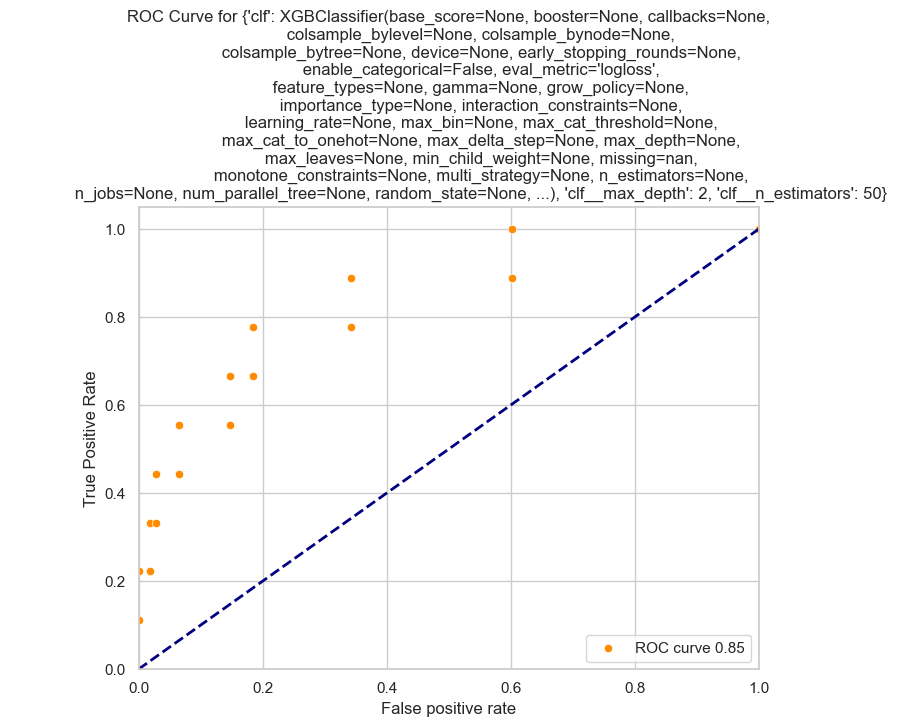

In [20]:
plotRocAucCuve(myGridSearchCv, X_test, y_test)

[Text(0.5, 0.8333333333333334, 'J0_KNAUS <= 0.5\ngini = 0.125\nsamples = 296\nvalue = [433.0, 31.0]\nclass = NOCPC12'),
 Text(0.25, 0.5, 'J0_PAD <= -0.339\ngini = 0.257\nsamples = 54\nvalue = [73, 13]\nclass = NOCPC12'),
 Text(0.125, 0.16666666666666666, 'gini = 0.469\nsamples = 18\nvalue = [15, 9]\nclass = NOCPC12'),
 Text(0.375, 0.16666666666666666, 'gini = 0.121\nsamples = 36\nvalue = [58, 4]\nclass = NOCPC12'),
 Text(0.75, 0.5, 'J0_VT <= 1.937\ngini = 0.091\nsamples = 242\nvalue = [360, 18]\nclass = NOCPC12'),
 Text(0.625, 0.16666666666666666, 'gini = 0.082\nsamples = 239\nvalue = [359, 16]\nclass = NOCPC12'),
 Text(0.875, 0.16666666666666666, 'gini = 0.444\nsamples = 3\nvalue = [1, 2]\nclass = CPC12')]

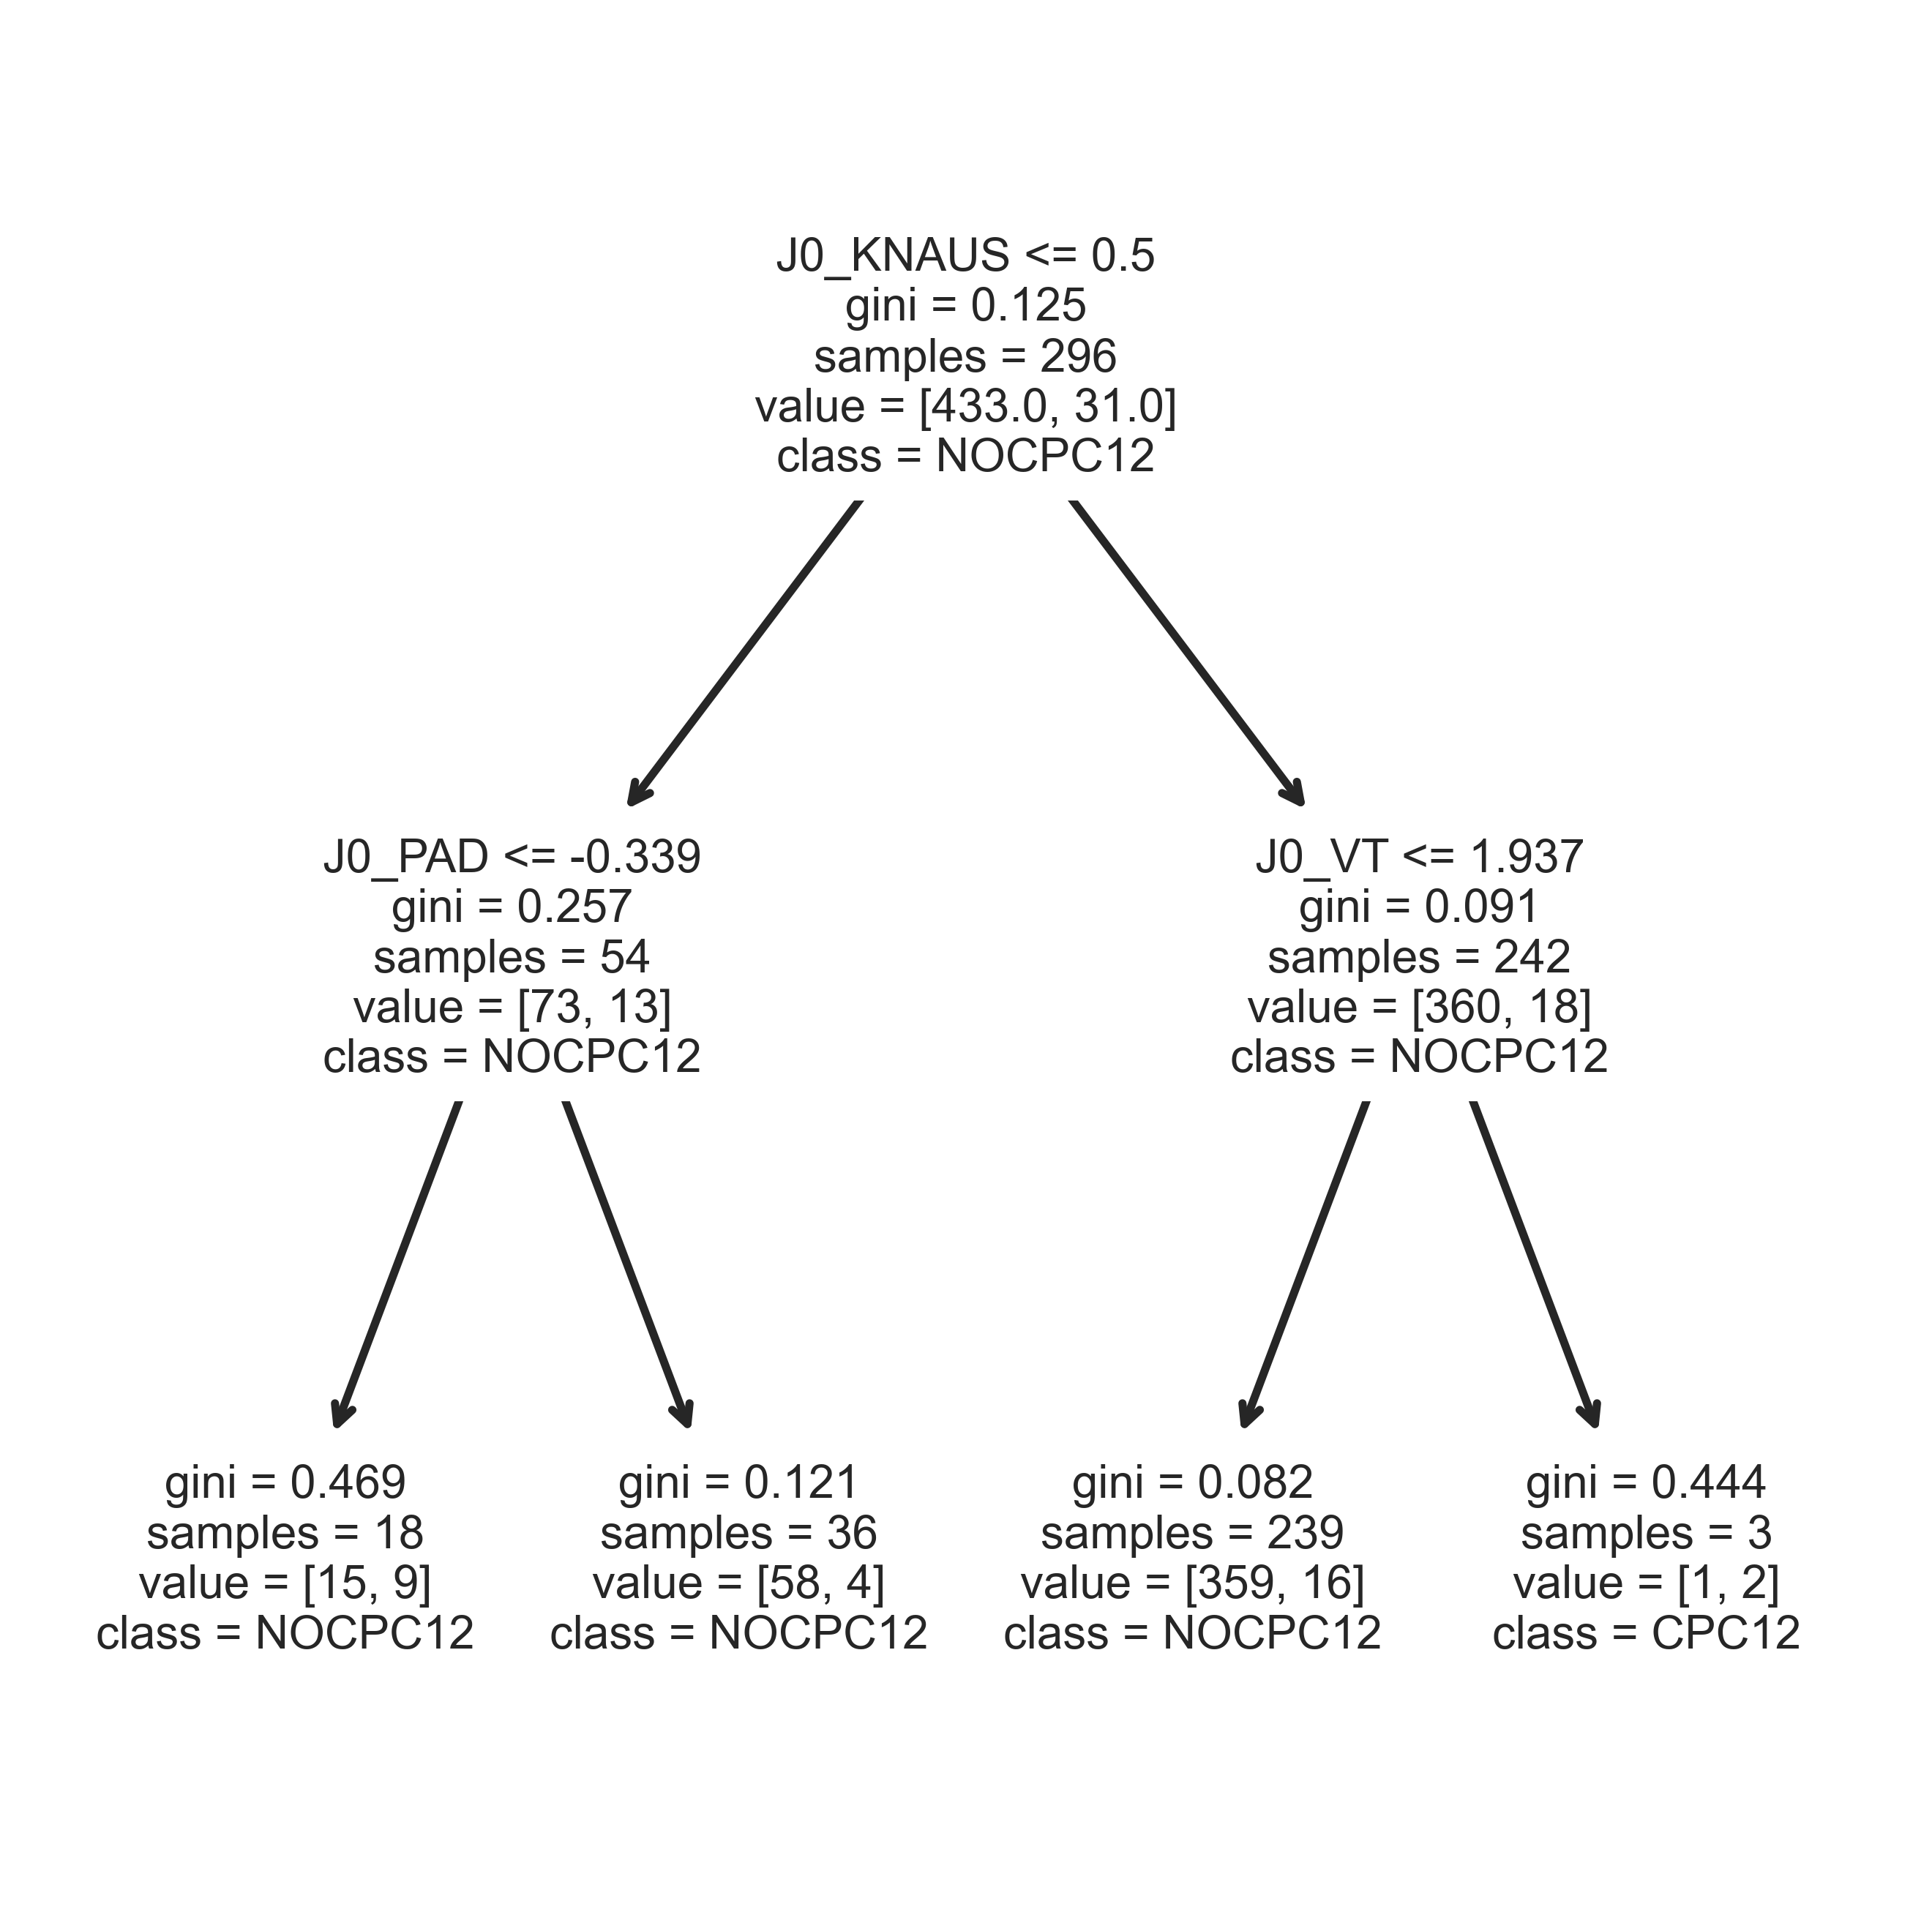

In [187]:
fig, axes = plt.subplots(ncols = 1, nrows = 1, figsize=(4,4), dpi=800)
tree.plot_tree(myBestModel.named_steps['clf'].estimators_[3],  feature_names=list(myNumericalColumns) + list(myCategoricalColumns), class_names = {1:'CPC12', 0:'NOCPC12'})
# tree.plot_tree(myBestModel.named_steps['clf'],  feature_names=list(myNumericalColumns) + list(myCategoricalColumns), class_names = {1:'CPC12', 0:'NOCPC12'})

In [103]:
len(myBestModel.named_steps['clf'].estimators_)

AttributeError: 'XGBClassifier' object has no attribute 'estimators_'

In [104]:
myModel = myBestModel.named_steps['clf']
myModel.feature_names = list(myNumericalColumns) + list(myCategoricalColumns)
myDotData = to_graphviz(myModel)
# myPydotGraph = pydot.graph_from_dot_data(myDotData.source)[0]
def replaceData(dot_data, names):
  for i, name in enumerate(names):
    dot_data = re.sub(f'f{i}<', name + '<', dot_data)
  return dot_data
myNewDot = replaceData(myDotData.source, myModel.feature_names)
with open('tree2.dot', 'w') as f:
  f.write(myNewDot)
# myPydotGraph.write_png('tree.png')
# Source.from_file('tree.dot')


In [436]:
myNewDf = pd.DataFrame(columns=myNumericalColumns)
myNewDf.loc[0, myNumericalColumns] = 0
myNewDf.loc[0, 'J0_ADRE_DOS'] = -0.829257727
myNewDf.loc[0, myNumericalColumns] = myBestModel.named_steps['preprocessor'].named_transformers_['num'].inverse_transform(myNewDf)
myNewDf['J0_ADRE_DOS']

0    1.5
Name: J0_ADRE_DOS, dtype: object

In [152]:
# myModel = XGBClassifier()
# myModel.fit(X_train, y_train)
# y_pred_proba = myModel.predict_proba(X_test)[:, 1]
# y_pred = myModel.predict(X_test)
# print(f'Area under the receiver operating curve is {roc_auc_score(y_test, y_pred_proba)}')
# print(f'Accuracy score is {accuracy_score(y_test, y_pred)}')
# roc_auc_scores = cross_val_score(myPipeline, X_train, y_train, cv = kf, scoring=myRocScorer)
# accuracy_scores = cross_val_score(myPipeline, X_train, y_train, cv = kf, scoring='accuracy')
# print(f'The cross val accuracy scores are {np.mean(accuracy_scores)}')
# print(f'The cross val roc auc scores are {np.mean(roc_auc_scores)}')
# y_pred_proba = myModel.predict_proba(X_test)[:, 1]
# y_pred = myModel.predict(X_test)



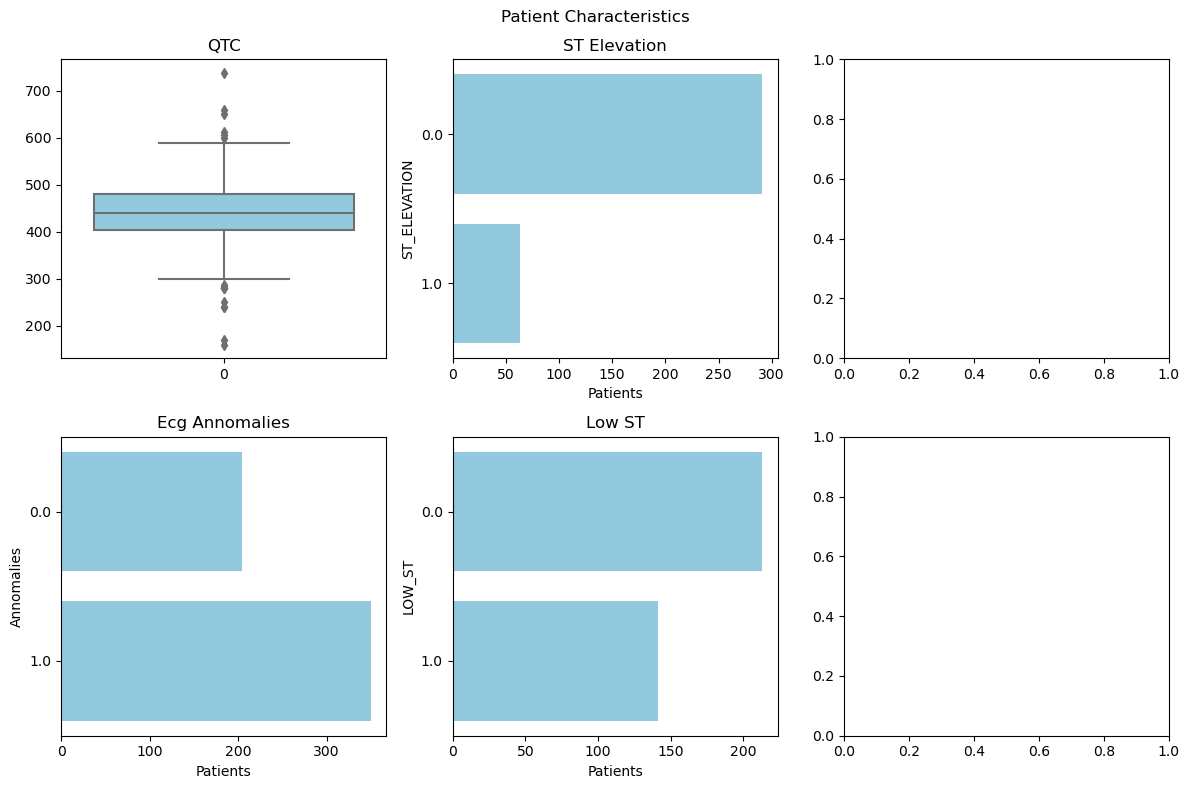

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
sns.boxplot(myPredictorsDf['ECG_QTC'], ax=axs[0][0], color='skyblue')
axs[0][0].set_title('QTC')
myColumn = 'ECG_SUS_ST'
myRename = 'ST_ELEVATION'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'ST_ELEVATION', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][1], color='skyblue', orient='h')
axs[0][1].set_title('ST Elevation')

myColumn = 'ECG_SOUS_ST'
myRename = 'LOW_ST'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'LOW_ST', x = 'Patients', data=myGroup.reset_index(), ax=axs[1][1], color='skyblue', orient='h')
axs[1][1].set_title('Low ST')

myColumn = 'ECG_ANOMALI'
myRename = 'Annomalies'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'Annomalies', x = 'Patients', data=myGroup.reset_index(), ax=axs[1][0], color='skyblue', orient='h')
axs[1][0].set_title('Ecg Annomalies')
fig.suptitle('Patient Characteristics')
plt.tight_layout()
plt.show()

In [184]:
ecg_columns

['SUBJID',
 'VISIT',
 'ECG',
 'ECG_QTC',
 'ECG_ANOMALI',
 'ECG_SUS_ST',
 'ECG_SOUS_ST',
 'ECG_BAVI',
 'ECG_BAVII',
 'ECG_BAVIII',
 'ECG_BBG',
 'ECG_BBD',
 'ECG_TACHICARD',
 'ECG_FIBRIL',
 'ECG_SALV_VENT',
 'ECG_FLUTER',
 'ECG_SALV_SUPRA']

KeyError: 0

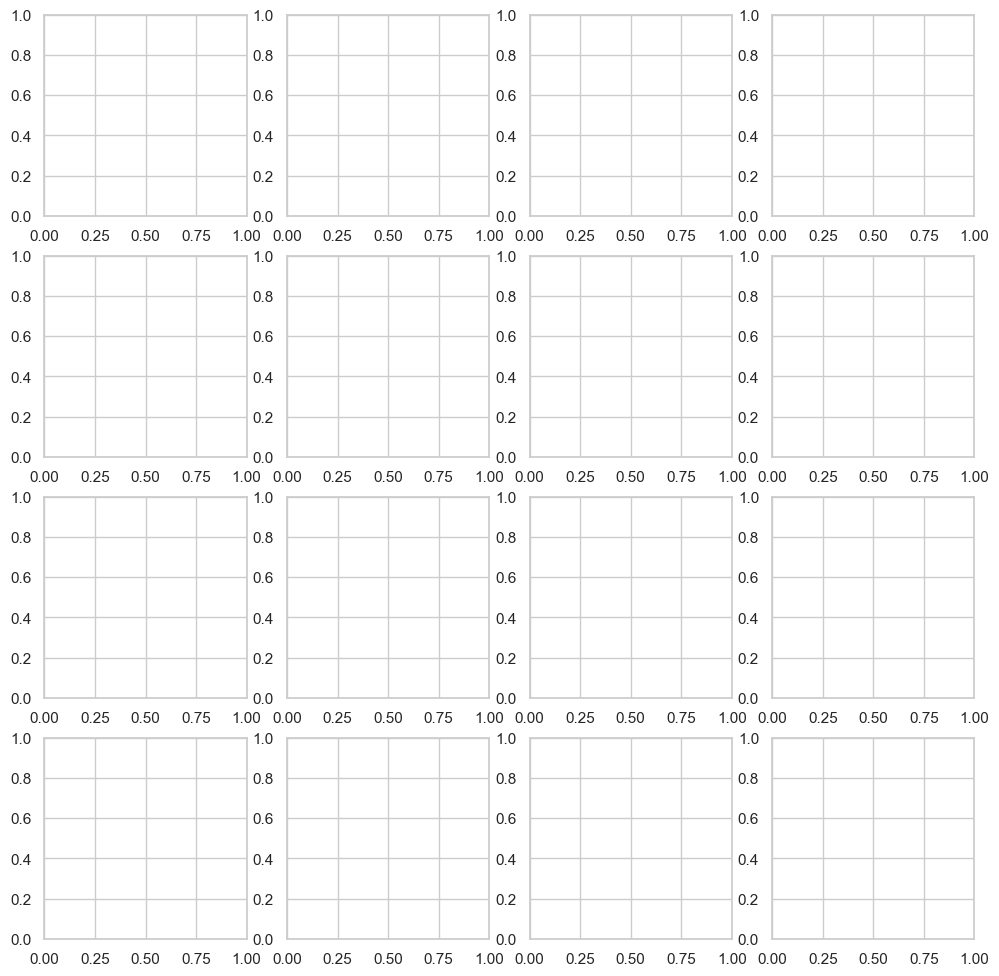

In [74]:
fig, axs = plt.subplots(4, 4, figsize=(12, 12))
ecg_columns2 = ecg_columns[3:]
for i, value in enumerate(ecg_columns2):
  myAxis = axs[i // 4, i % 4]
  if value == 'ECG_QTC':
    sns.boxplot(myPredictorsDf['ECG_QTC'], ax=myAxis, color='skyblue')
    myAxis.set_title('QTC')
  else:
    myGroup = getGroupByPatients(myPredictorsDf, value, value)
    sns.barplot(y = value, x = 'Patients', data=myGroup.reset_index(), ax=myAxis, color='skyblue', orient='h')
    myAxis.set_title(ecg_columns_descr[i + 2])
  # myPredictorsDf.groupby(value).agg({'SUBJID': 'count'}).plot(kind='barh', color = ['skyblue'], title = j0_reflex_columns_descr[i], ax = axs[i // 3, i % 3]) # change this to sns
plt.tight_layout()
plt.show()

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(12, 8))
sns.boxplot(myPredictorsDf['J0_AGE'], ax=axs[0][0], color='skyblue')
axs[0][0].set_title('Age')
sns.boxplot(myPredictorsDf['J0_BMI'], ax=axs[0][1], color='skyblue')
axs[0][1].set_title('BMI')
sns.boxplot(myPredictorsDf['J0_POIDS'], ax=axs[1][0], color='skyblue')
axs[1][0].set_title('Weight (kg)')
sns.boxplot(myPredictorsDf['J0_TAILLE'], ax=axs[1][1], color='skyblue')
axs[1][1].set_title('Height (cm)')
# sns.barplot(y = 'J0_SEX', x = 'SUBJID', hue='CPC12', data=myPredictorsDf.groupby(['J0_SEX', 'CPC12']).agg({'SUBJID': 'count'}).reset_index(), ax=axs[1][1])
myColumn = 'J0_SEX'
myRename = 'Sex'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename).rename({'Homme': 'Male', 'Femme': 'Female'})
sns.barplot(y = 'Sex', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][2], color='skyblue')
axs[0][2].set_title('Sex')
fig.suptitle('Patient Characteristics')
plt.tight_layout()
plt.show()

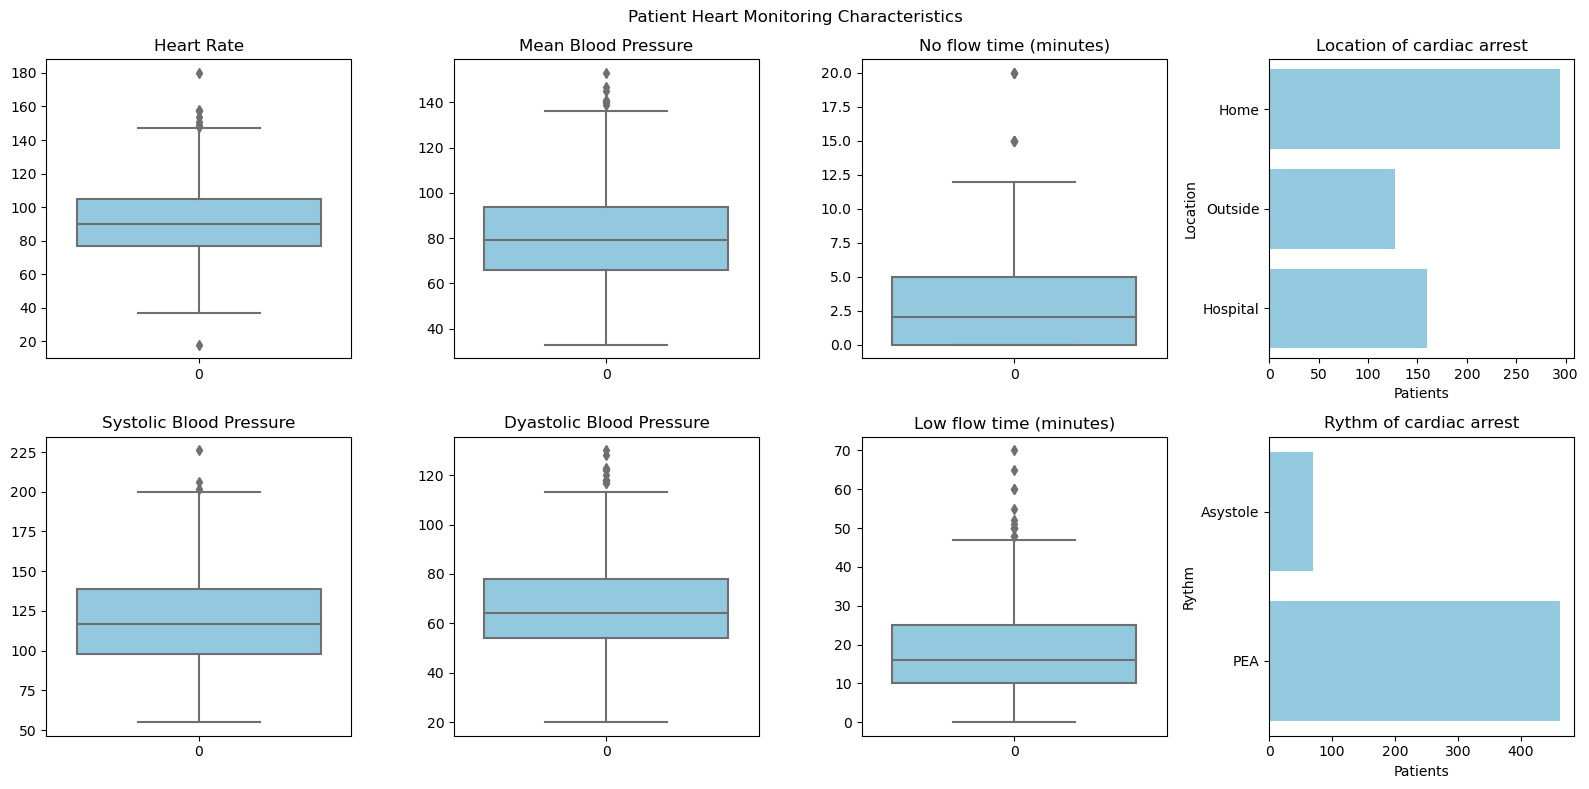

In [108]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
sns.boxplot(myPredictorsDf['J0_FC'], ax=axs[0][0], color='skyblue')
axs[0][0].set_title('Heart Rate')
sns.boxplot(myPredictorsDf['J0_PAM'], ax=axs[0][1], color='skyblue')
axs[0][1].set_title('Mean Blood Pressure')
sns.boxplot(myPredictorsDf['J0_PAS'], ax=axs[1][0], color='skyblue')
axs[1][0].set_title('Systolic Blood Pressure')
sns.boxplot(myPredictorsDf['J0_PAD'], ax=axs[1][1], color='skyblue')
axs[1][1].set_title('Dyastolic Blood Pressure')
sns.boxplot(myPredictorsDf['J0_NOFLOW'], ax=axs[0][2], color='skyblue')
axs[0][2].set_title('No flow time (minutes)')
sns.boxplot(myPredictorsDf['J0_LOWFLOW'], ax=axs[1][2], color='skyblue')
axs[1][2].set_title('Low flow time (minutes)')
fig.suptitle('Patient Heart Health')
# ADD acr location and rythm heere
myColumn = 'J0_LIEU_ACR'
myRename = 'Location'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename).rename({1: 'Home', 2: 'Outside', 3: 'Hospital'})
sns.barplot(y = 'Location', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][3], color='skyblue')
axs[0][3].set_title('Location of cardiac arrest')

myColumn = 'J0_RYTHM'
myRename = 'Rythm'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename).rename({1: 'Asystole', 2: 'PEA'})
sns.barplot(y = 'Rythm', x = 'Patients', data=myGroup.reset_index(), ax=axs[1][3], color='skyblue')
axs[1][3].set_title('Rythm of cardiac arrest')

plt.tight_layout()
plt.show()

<Axes: title={'center': 'Man vs. Woman Quantity'}, ylabel='J0_SEX'>

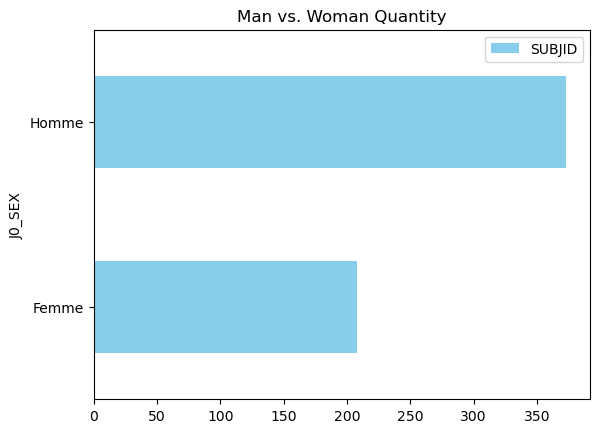

In [ ]:
myPredictorsDf.groupby('J0_SEX').agg({'SUBJID': 'count'}).plot(kind='barh', color = ['skyblue'], title = 'Man vs. Woman Quantity')

In [150]:
myColumn = 'J0_RYTHM'
myRename = 'Rythm'
getGroupByPatients(myPredictorsDf, myColumn, myRename).rename({1: 'Asystole', 2: 'PEA'})

,Patients
Rythm,


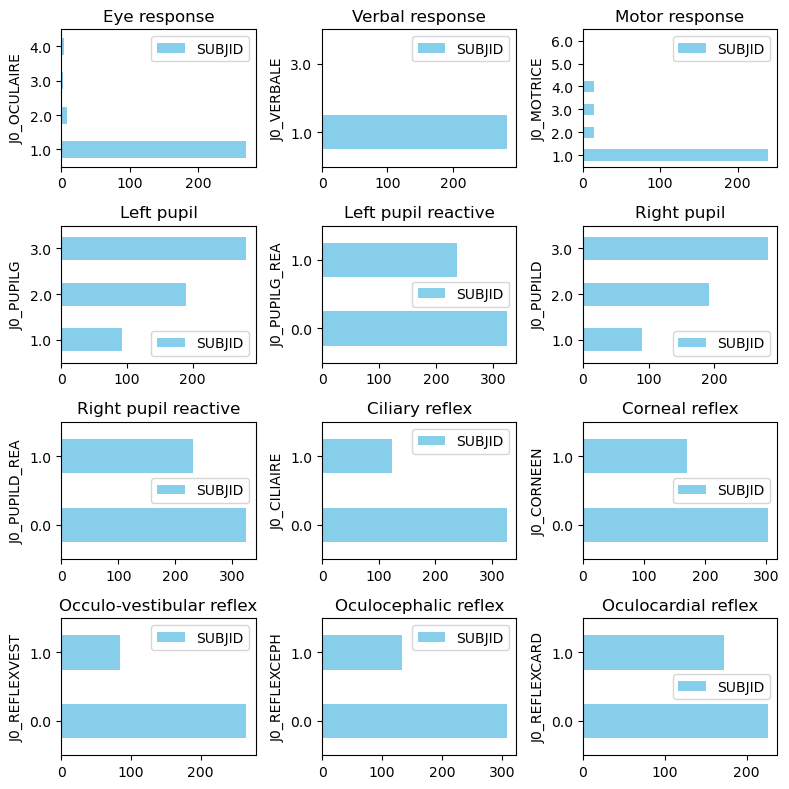

In [67]:
fig, axs = plt.subplots(4, 3, figsize=(8, 8))
for i, value in enumerate(j0_reflex_columns):
  myPredictorsDf.groupby(value).agg({'SUBJID': 'count'}).plot(kind='barh', color = ['skyblue'], title = j0_reflex_columns_descr[i], ax = axs[i // 3, i % 3]) # change this to sns
plt.tight_layout()
plt.show()

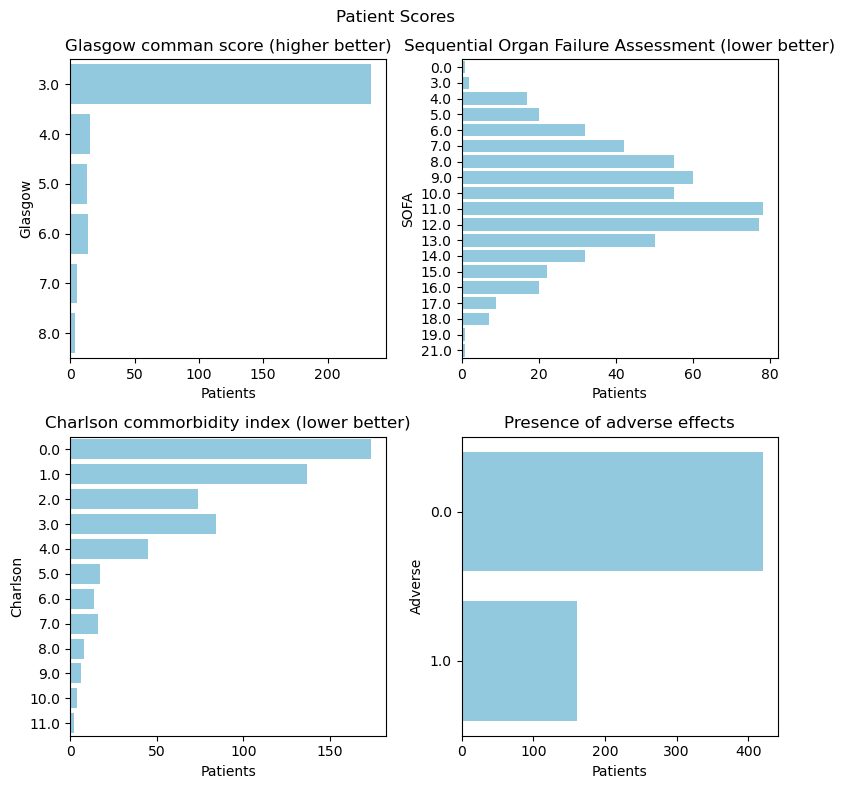

In [160]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
# ADD acr location and rythm heere
myColumn = 'J0_GLASGOW'
myRename = 'Glasgow'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'Glasgow', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][0], color='skyblue', orient='h')
axs[0][0].set_title('Glasgow comman score (higher better)')

myColumn = 'SOFA_SC'
myRename = 'SOFA'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'SOFA', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][1], color='skyblue', orient='h')
axs[0][1].set_title('Sequential Organ Failure Assessment (lower better)')

myColumn = 'J0_CHARLSON'
myRename = 'Charlson'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'Charlson', x = 'Patients', data=myGroup.reset_index(), ax=axs[1][0], color='skyblue', orient='h')
axs[1][0].set_title('Charlson commorbidity index (lower better)')

myColumn = 'EI_EI'
myRename = 'Adverse'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'Adverse', x = 'Patients', data=myGroup.reset_index(), ax=axs[1][1], color='skyblue', orient='h')
axs[1][1].set_title('Presence of adverse effects')

fig.suptitle('Patient Scores')

plt.tight_layout()
plt.show()

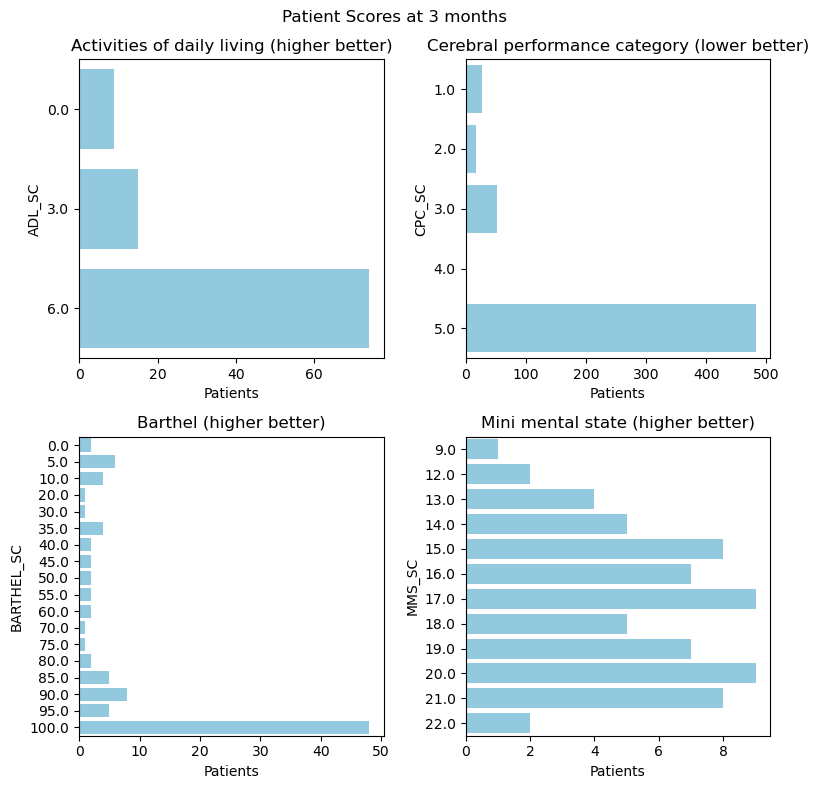

In [173]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
# ADD acr location and rythm heere
myColumn = 'ADL_SC'
myRename = 'ADL_SC'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'ADL_SC', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][0], color='skyblue', orient='h')
axs[0][0].set_title('Activities of daily living (higher better)')

myColumn = 'CPC_SC3'
myRename = 'CPC_SC'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'CPC_SC', x = 'Patients', data=myGroup.reset_index(), ax=axs[0][1], color='skyblue', orient='h')
axs[0][1].set_title('Cerebral performance category (lower better)')

myColumn = 'BARTHEL_SC'
myRename = 'BARTHEL_SC'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'BARTHEL_SC', x = 'Patients', data=myGroup.reset_index(), ax=axs[1][0], color='skyblue', orient='h')
axs[1][0].set_title('Barthel (higher better)')

myColumn = 'MMS_SC'
myRename = 'MMS_SC'
myGroup = getGroupByPatients(myPredictorsDf, myColumn, myRename)
sns.barplot(y = 'MMS_SC', x = 'Patients', data=myGroup.reset_index(), ax=axs[1][1], color='skyblue', orient='h')
axs[1][1].set_title('Mini mental state (higher better)')

fig.suptitle('Patient Scores at 3 months')

plt.tight_layout()
plt.show()

In [219]:
corr = myPredictorsDf.corr()
corr1 = myPredictorsDf[myPredictorsDf['groupe'] == 1].corr()
corr2 = myPredictorsDf[myPredictorsDf['groupe'] == 0].corr()
myDiff = corr1 - corr2
# print(corr2)

C:\Users\mbranda1\AppData\Local\Temp\ipykernel_16256\3520459876.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = myPredictorsDf.corr()
C:\Users\mbranda1\AppData\Local\Temp\ipykernel_16256\3520459876.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr1 = myPredictorsDf[myPredictorsDf['groupe'] == 1].corr()
C:\Users\mbranda1\AppData\Local\Temp\ipykernel_16256\3520459876.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr2 = myPredictorsDf[myPredictorsDf['grou

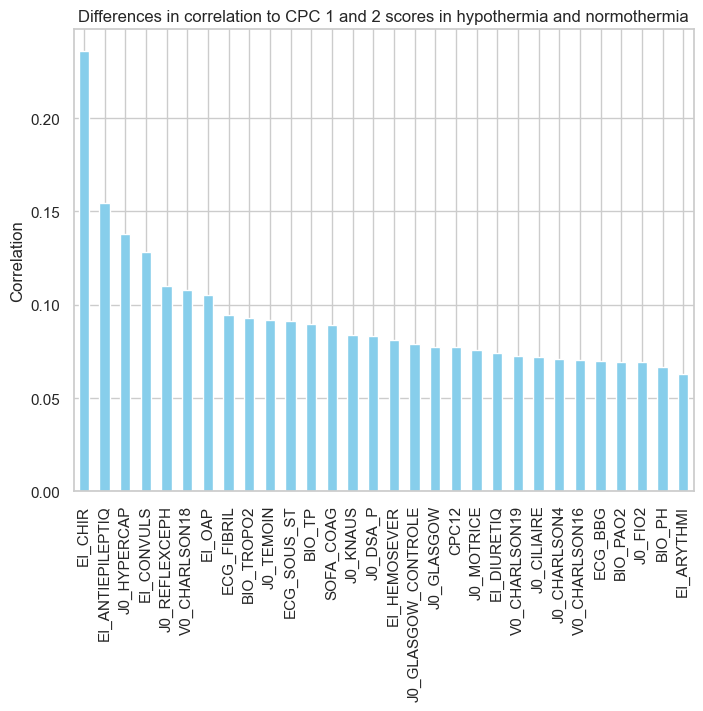

In [220]:
top_corr = corr['groupe'].abs().sort_values(ascending=False)[4:]
top_corr = top_corr[:30]
plt.figure(figsize=(8,6))
top_corr.plot(kind = 'bar', color = 'skyblue')
plt.title('Differences in correlation to CPC 1 and 2 scores in hypothermia and normothermia')
plt.ylabel('Correlation')
plt.show()

In [ ]:
myPredictorsDf = getType(myPredictorsDf)

In [ ]:
myPredictorsDf.groupby('Type')['J0_REFLEXVEST'].describe(percentiles=quantile_values)

In [ ]:
myPredictorsDf.groupby('Type')['J0_CILIAIRE'].describe(percentiles=quantile_values)

In [ ]:
model = ols('CPC12 ~ groupe', data=myPredictorsDf).fit()
anova_table = sm.stats.anova_lm(model, typ=2) 
print(anova_table)

In [ ]:
turkey = pairwise_tukeyhsd(endog=myPredictorsDf['CPC12'], groups=myPredictorsDf['groupe'], alpha=0.05)
print(turkey)

In [ ]:
# top_corr = corr['CPC12'].sort_values(ascending=False)[3:33]
myGroup = 1
X = sm.add_constant(myPredictorsDf.drop(columns=['CPC12', 'CPC_SC3', 'CPC12Hyp', 'CPC12Norm', 'Type', 'J0_CAUSE2_ACR_P', 'J0_H_37T1', 'J0_SEX', 'VISIT']).fillna(0)[myPredictorsDf['groupe'] == myGroup])#[top_corr.index])
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X)).reindex()
X_scaled.columns = X.columns
model = sm.OLS(myPredictorsDf[myPredictorsDf['groupe'] == myGroup]['CPC12'].reset_index().drop(columns='index'), X_scaled).fit()
print(model.summary())

In [ ]:
myGroup = 1
X = sm.add_constant(myPredictorsDf.drop(columns=['CPC12', 'CPC_SC3', 'CPC12Hyp', 'CPC12Norm', 'Type', 'J0_CAUSE2_ACR_P', 'J0_H_37T1', 'J0_SEX', 'VISIT']).fillna(0))#[top_corr.index])
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X)).reindex()
X_scaled.columns = X.columns
model = sm.OLS(myPredictorsDf['CPC12'].reset_index().drop(columns='index'), X_scaled).fit()
print(model.summary())

In [ ]:
top_corr = model.pvalues.abs()[model.pvalues.abs() < 0.2].sort_values(ascending=True)
top_corr = model.params[top_corr.index]
plt.figure(figsize=(8,6))
top_corr.plot(kind = 'bar', color = 'skyblue')
plt.title('Significant variables in ANOVA normalized')
plt.ylabel('Coefficients')
plt.show()

In [ ]:
model.pvalues.abs()[model.pvalues.abs() < 0.2]

In [ ]:
myPredictorsDf.groupby(['Type', 'J0_O2']).agg({'SUBJID': 'count'})

In [ ]:
myPredictorsDf.groupby(['Type'])['J0_ADRE2'].describe(percentiles=quantile_values)

In [ ]:
myPredictorsDf.groupby(['Type'])['J0_DSA_P'].describe(percentiles=quantile_values)

In [ ]:
myPredictorsDf.groupby(['Type'])['J0_REFLEXVEST'].describe(percentiles=quantile_values)

In [ ]:
X

In [ ]:
X_scaled

In [ ]:
myPredictorsDf[myPredictorsDf['groupe'] == 1]['CPC12'].reset_index().drop(columns='index')

In [ ]:
X = sm.add_constant(myPredictorsDf.drop(columns=['CPC12', 'CPC_SC3', 'CPC12Hyp', 'CPC12Norm', 'Type', 'J0_CAUSE2_ACR_P', 'J0_H_37T1', 'J0_SEX', 'VISIT']).fillna(0))#[top_corr.index])
X_scaled = pd.DataFrame(StandardScaler().fit_transform(X)).reindex()
X_scaled.columns = X.columns
classifier = XGBClassifier(max_depth = 5)
classifier.fit(X_scaled, myPredictorsDf['CPC12'])
ypred = classifier.predict(X_scaled)
accuracy = accuracy_score(ypred, myPredictorsDf['CPC12'])
print(f'Accuracy is {accuracy}')
plot_tree(classifier)